In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


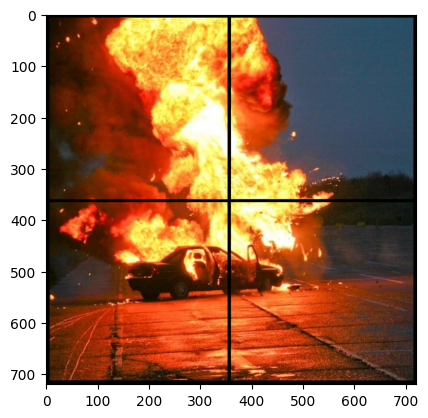

In [2]:
meledak_bgr = cv.imread('Assets/Meledak.PNG')
meledak = cv.cvtColor(meledak_bgr, cv.COLOR_BGR2RGB)
plt.imshow(meledak)
plt.show()

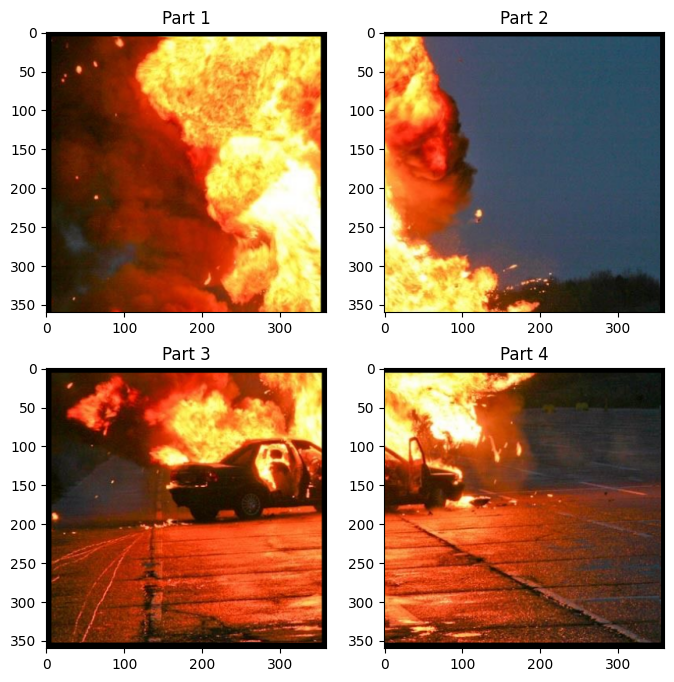

In [3]:
# Dapatkan dimensi gambar
h, w, c = meledak.shape
mid_h, mid_w = h // 2, w // 2

# 2. Proses Slicing (Membagi jadi 4 bagian)
part1 = meledak[:mid_h, :mid_w]       # Kiri Atas
part2 = meledak[:mid_h, mid_w:]       # Kanan Atas
part3 = meledak[mid_h:, :mid_w]       # Kiri Bawah
part4 = meledak[mid_h:, mid_w:]       # Kanan Bawah

# Menampilkan hasil slicing
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(part1); axs[0, 0].set_title('Part 1')
axs[0, 1].imshow(part2); axs[0, 1].set_title('Part 2')
axs[1, 0].imshow(part3); axs[1, 0].set_title('Part 3')
axs[1, 1].imshow(part4); axs[1, 1].set_title('Part 4')
plt.show()

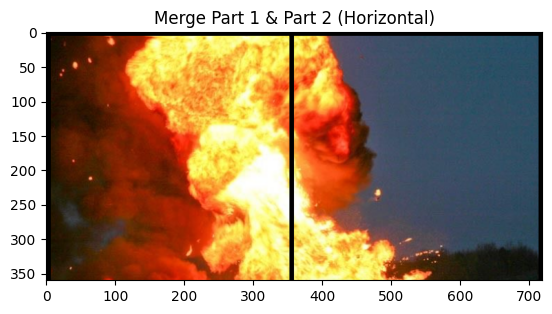

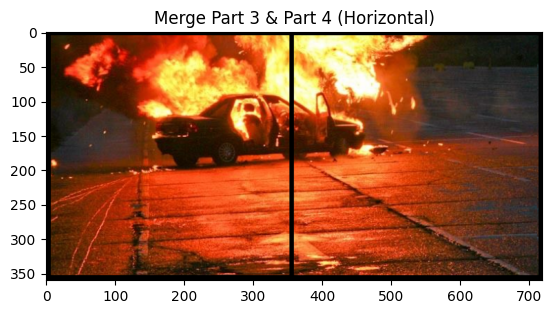

In [21]:
def merge_image(image1, image2, orientation='H'):
    if orientation == 'H':
        height = max(image1.shape[0], image2.shape[0])
        total_width = image1.shape[1] + image2.shape[1]
        if len(image1.shape) == 2:
            merged = np.zeros((height, total_width), dtype=image1.dtype)
        else:
            merged = np.zeros((height, total_width, image1.shape[2]), dtype=image1.dtype)
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1
        merged[0:image2.shape[0], image1.shape[1]:image1.shape[1]+image2.shape[1]] = image2
    else:
        total_height = image1.shape[0] + image2.shape[0]
        width = max(image1.shape[1], image2.shape[1])
        if len(image1.shape) == 2:
            merged = np.zeros((total_height, width), dtype=image1.dtype)
        else:
            merged = np.zeros((total_height, width, image1.shape[2]), dtype=image1.dtype)
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1
        merged[image1.shape[0]:image1.shape[0]+image2.shape[0], 0:image2.shape[1]] = image2
    return merged

plt.imshow(merge_image(part1, part2, orientation='H'))
plt.title('Merge Part 1 & Part 2 (Horizontal)')
plt.show()

plt.imshow(merge_image(part3, part4, orientation='H'))
plt.title('Merge Part 3 & Part 4 (Horizontal)')
plt.show()


Text(0.5, 1.0, 'Kembang')

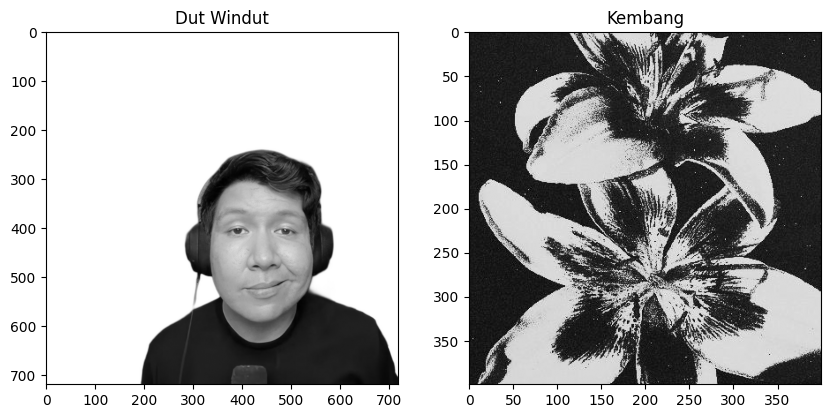

In [11]:
dutwindut = cv.imread('Assets/Windut.PNG', cv.IMREAD_GRAYSCALE)
kembang = cv.imread('Assets/Bunga.PNG', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(dutwindut, cmap='gray')
plt.title('Dut Windut')

plt.subplot(1, 2, 2)
plt.imshow(kembang, cmap='gray')
plt.title('Kembang')


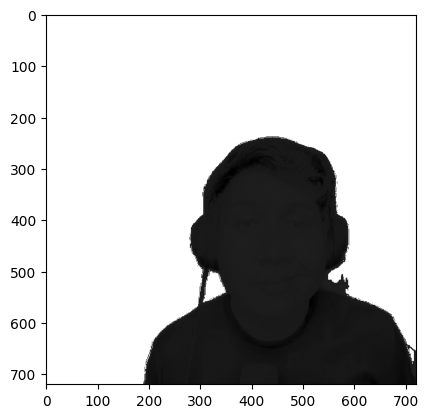

In [16]:
def histogram_specification(source_image, target_image):
    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            hist_source[int(source_image[i, j])] += 1

    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):
            hist_target[int(target_image[i, j])] += 1

    cdf_source = np.cumsum(hist_source).astype(float)
    cdf_target = np.cumsum(hist_target).astype(float)

    cdf_source /= cdf_source[-1]
    cdf_target /= cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)
    j = 0
    for i in range(256):
        while j < 255 and cdf_target[j] < cdf_source[i]:
            j += 1
        map_hist[i] = j

    result = np.zeros(source_image.shape, dtype=np.uint8)
    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            result[i, j] = map_hist[int(source_image[i, j])]

    return result


plt.imshow(histogram_specification(dutwindut, kembang), cmap='gray')
plt.show()


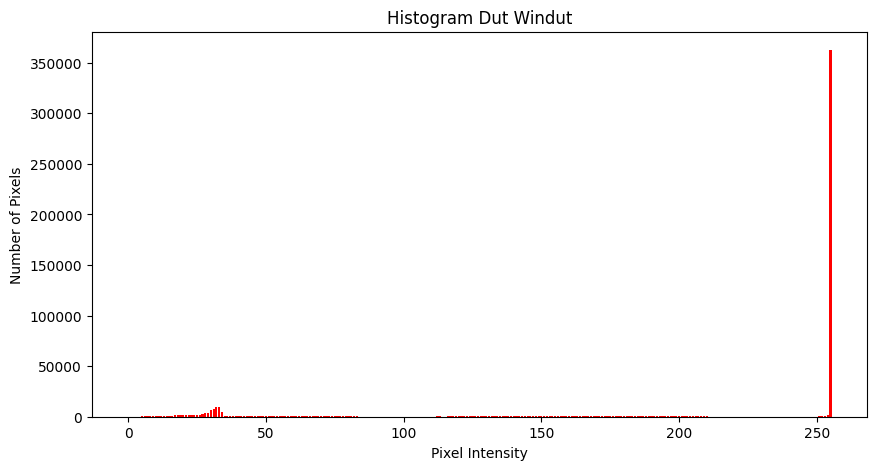

In [19]:
def make_hist(image):
    histogram = [0] * 256
    
    height = len(image)
    width = len(image[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(image[i][j])
            histogram[val] += 1
    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Pixel Intensity")
    plt.title(title)
    plt.ylabel("Number of Pixels")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()
    
plot_histogram(make_hist(dutwindut), "Histogram Dut Windut", "red")